<a href="https://colab.research.google.com/github/MiteshPatole/Master-Thesis/blob/main/IoT_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn.model_selection
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import sklearn.decomposition
import imblearn.over_sampling
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import IncrementalPCA
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
df=pd.read_csv('cleaned_data.csv')
df.head()
df = df.sample(5000)

In [ ]:

print("\nMissing values in the dataset")
print(df.isna().sum())


Missing values in the dataset
duration             0
orig_bytes           0
resp_bytes           0
missed_bytes         0
orig_pkts            0
orig_ip_bytes        0
resp_pkts            0
resp_ip_bytes        0
label                0
proto_icmp           0
proto_tcp            0
proto_udp            0
conn_state_OTH       0
conn_state_REJ       0
conn_state_RSTO      0
conn_state_RSTOS0    0
conn_state_RSTR      0
conn_state_RSTRH     0
conn_state_S0        0
conn_state_S1        0
conn_state_S2        0
conn_state_S3        0
conn_state_SF        0
conn_state_SH        0
conn_state_SHR       0
dtype: int64


In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    df.nunique()
    print(f"Unique values in column '{column}': {unique_values}")

Unique values in column 'duration': [0.270351 0.367911 0.025734 ... 0.003952 2.998233 3.153212]
Unique values in column 'orig_bytes': [       0      589       29      107       48       18       62       40
      111       47     3000       67      605       75       45      336
       33     6164       68       63      180      192       78       39
      385      318       37      206      636      804     1847       82
       60       79      537       90       80      120       46      158
      119      518      201      440      597       96      288       56
      241      450       88       64       43       38      104       34
       54      400       76       95 25052300      560      894     3624
      421      212       41 75546624      581      139     5652       72
       74      102       89      100      135      173       53      134
      220      103       51       85      670      106      703       66
  7895522       91      292      165     1560      283      168

In [ ]:
df.isna().sum()

,0
duration,0
orig_bytes,0
resp_bytes,0
missed_bytes,0
orig_pkts,0
orig_ip_bytes,0
resp_pkts,0
resp_ip_bytes,0
label,0
proto_icmp,0


In [ ]:
x_train = df.drop(["label"],axis = 1)
y_train = df["label"]

x_test = df.drop(["label"],axis=1)
y_test = df["label"]

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (5000, 24)
x_test: (5000, 24)
y_train: (5000,)
y_test: (5000,)


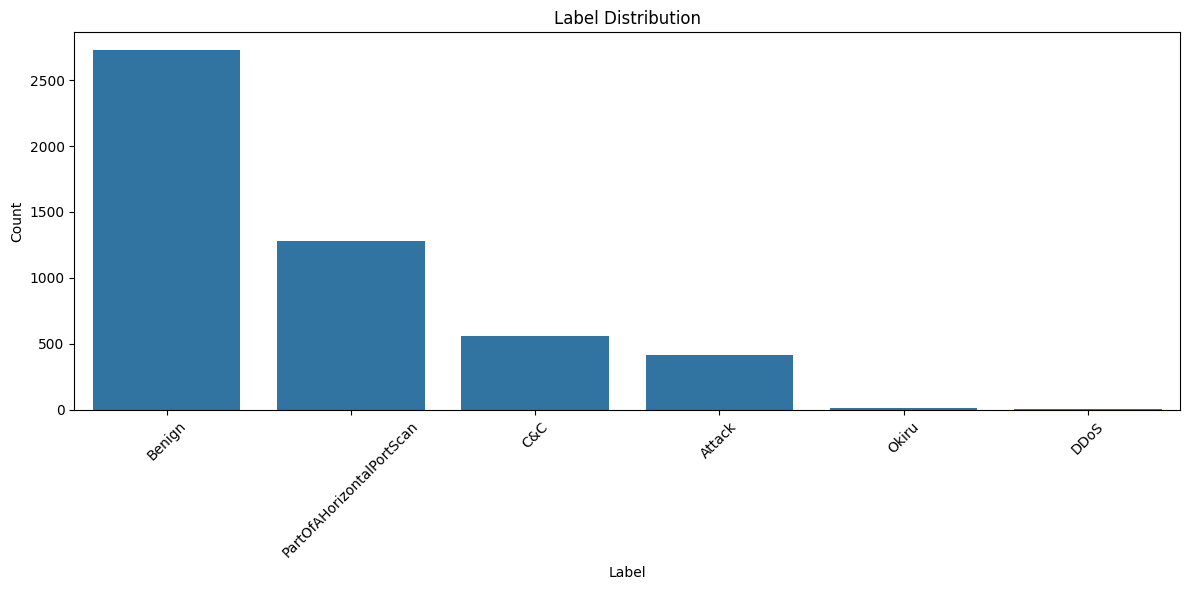

In [ ]:


# Example: if you have your labels in a DataFrame column called 'Label'
# If you have an array of labels instead, you can convert it into a DataFrame
# For instance: df = pd.DataFrame({'Label': y_train})


# If your label column is named differently, change 'Label' to the correct column name
plt.figure(figsize=(12, 6))
sns.countplot(df, x='label', order=df['label'].value_counts().index)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate labels to avoid overlap if needed
plt.tight_layout()
plt.show()


In [ ]:
# Scaling the data
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:

encoder = OneHotEncoder(handle_unknown='ignore')
x_train_encoded = encoder.fit_transform(x_train)
x_test_encoded = encoder.transform(x_test)

In [ ]:


ipca = IncrementalPCA(n_components=24, batch_size=200)
x_train_transformed = ipca.fit_transform(x_train)
x_test_transformed = ipca.transform(x_test)

In [ ]:


ros = RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)
print("x_train_resampled size:", x_train_resampled.shape)
print("y_train_resampled size:", y_train_resampled.shape)

x_train_resampled size: (16356, 24)
y_train_resampled size: (16356,)


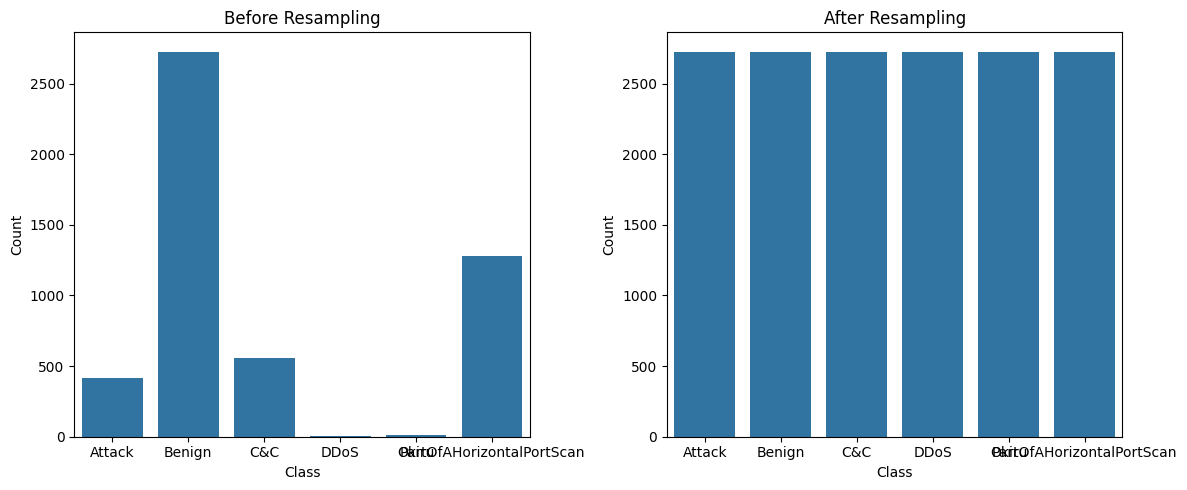

In [ ]:


# --- 1. Class Distribution Visualization ---
counts_before = pd.Series(y_train).value_counts().sort_index()
counts_after = pd.Series(y_train_resampled).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot: BEFORE
sns.barplot(x=counts_before.index, y=counts_before.values, ax=axes[0])
axes[0].set_title("Before Resampling")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Right subplot: AFTER
sns.barplot(x=counts_after.index, y=counts_after.values, ax=axes[1])
axes[1].set_title("After Resampling")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:


parameters_ranfor = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [10, 15]
}


model_ranfor = RandomForestClassifier(random_state=42)

subset_size = 10000
x_subset = x_train_resampled[:subset_size]
y_subset = y_train_resampled[:subset_size]

clf_model_ranfor = RandomizedSearchCV(
    model_ranfor,
    parameters_ranfor,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    n_iter=5,
    random_state=42,
    verbose=2
)

start_time = time.time()
clf_model_ranfor.fit(x_subset, y_subset)
elapsed_time = time.time() - start_time

print("Elapsed time: {:.2f} seconds".format(elapsed_time))
print("Accuracy of best Random Forest Classifier = {:.2f}".format(clf_model_ranfor.best_score_))
print("Best found hyperparameters = {}".format(clf_model_ranfor.best_params_))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Elapsed time: 32.57 seconds
Accuracy of best Random Forest Classifier = 0.91
Best found hyperparameters = {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None}


In [ ]:
y_predicted=clf_model_ranfor.predict(x_test)
accuracy=sklearn.metrics.accuracy_score(y_test,y_predicted)
cm=sklearn.metrics.confusion_matrix(y_test,y_predicted)
precision,recall,f1,support=sklearn.metrics.precision_recall_fscore_support(y_test,y_predicted)

print("Accuracy =",accuracy)
print("Precision",precision)
print("Recall",recall)
print("F1-score",f1)
print("Confusion Matrix:\n",cm)

Accuracy = 0.9478
Precision [1.         0.97976654 0.74206897 1.         1.         0.98271799]
Recall [1.         0.92369773 0.96243292 1.         0.77777778 0.9765808 ]
F1-score [1.         0.95090634 0.83800623 1.         0.875      0.97963978]
Confusion Matrix:
 [[ 418    0    0    0    0    0]
 [   0 2518  186    0    0   22]
 [   0   21  538    0    0    0]
 [   0    0    0    7    0    0]
 [   0    2    0    0    7    0]
 [   0   29    1    0    0 1251]]


In [ ]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler


parameters_svm = {
    'C': [0.01, 0.1, 10, 20],
    'kernel': ['rbf', 'linear']
}


model_svm = SVC(probability=True, random_state=42)


clf_model_svm = GridSearchCV(
    model_svm,
    parameters_svm,
    cv=2,
    n_jobs=-1,
    verbose=2
)

subset_size = 1000
x_subset = x_train_resampled[:subset_size]
y_subset = y_train_resampled[:subset_size]


scaler = StandardScaler()
x_subset_scaled = scaler.fit_transform(x_subset)

start_time = time.time()
clf_model_svm.fit(x_subset_scaled, y_subset)
elapsed_time = time.time() - start_time


Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


In [ ]:
y_predicted=clf_model_ranfor.predict(x_test)
accuracy=sklearn.metrics.accuracy_score(y_test,y_predicted)
cm=sklearn.metrics.confusion_matrix(y_test,y_predicted)
precision,recall,f1,support=sklearn.metrics.precision_recall_fscore_support(y_test,y_predicted)

print("Accuracy =",accuracy)
print("Precision",precision)
print("Recall",recall)
print("F1-score",f1)
print("Confusion Matrix:\n",cm)

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

parameters_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}


model_knn = KNeighborsClassifier()


clf_model_knn = GridSearchCV(
    model_knn,
    parameters_knn,
    cv=2,
    n_jobs=-1,
    verbose=2
)


subset_size = 1000
x_subset = x_train_resampled[:subset_size]
y_subset = y_train_resampled[:subset_size]


scaler_knn = StandardScaler()
x_subset_scaled = scaler_knn.fit_transform(x_subset)

start_time = time.time()
clf_model_knn.fit(x_subset_scaled, y_subset)
elapsed_time = time.time() - start_time

print("Elapsed time for KNN: {:.2f} seconds".format(elapsed_time))
print("Accuracy of best KNN Classifier = {:.2f}".format(clf_model_knn.best_score_))
print("Best found hyperparameters for KNN = {}".format(clf_model_knn.best_params_))


In [ ]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


parameters_tree = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}


model_tree = DecisionTreeClassifier(random_state=42)


clf_model_tree = GridSearchCV(
    model_tree,
    parameters_tree,
    cv=2,
    n_jobs=-1,
    verbose=2
)


subset_size = 1000
x_subset_tree = x_train_resampled[:subset_size]
y_subset_tree = y_train_resampled[:subset_size]

start_time = time.time()
clf_model_tree.fit(x_subset_tree, y_subset_tree)
elapsed_time = time.time() - start_time

print("Elapsed time for Decision Tree: {:.2f} seconds".format(elapsed_time))
print("Accuracy of best Decision Tree Classifier = {:.2f}".format(clf_model_tree.best_score_))
print("Best found hyperparameters for Decision Tree = {}".format(clf_model_tree.best_params_))


In [ ]:
# prompt: give me code for bar plot for accuracy of all the models

import matplotlib.pyplot as plt

# Assuming you have the accuracy scores for each model stored in a dictionary
model_accuracies = {
    'Random Forest': accuracy,  # Replace with actual accuracy from RandomForestClassifier
    'SVM': accuracy,  # Replace with actual accuracy from SVC
    'KNN': clf_model_knn.best_score_,  # Replace with actual accuracy from KNeighborsClassifier
    'Decision Tree': clf_model_tree.best_score_,  # Replace with actual accuracy from DecisionTreeClassifier
}

models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'salmon', 'lightgreen', 'lightcoral'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy of Different Classification Models")
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.show()
